In [6]:
%matplotlib inline

import torch
from torch import Tensor
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader
import torchmetrics
from datasets import load_dataset
import tiktoken
import math


class WMT14(Dataset):
    def __init__(self, data_split, num_rows, tokblk_size):
        super().__init__()
        s = f"{data_split}[:{num_rows}]"
        self.df = load_dataset("wmt/wmt14", "fr-en", split=s).data.to_pandas()
        self.rows: list[tuple[Tensor, Tensor] | None] = [None for _ in range(num_rows)]
        self.encoder = tiktoken.get_encoding("r50k_base")
        self.pad_token = self.encoder.n_vocab
        self.tokblk_size = tokblk_size

    def __len__(self):
        return self.df.shape[0]

    def vocab_size(self):
        return self.encoder.n_vocab + 1

    def tokenize(self, sentence):
        text = "<|startoftext|>" + sentence.lower() + "<|endoftext|>"
        tokens = self.encoder.encode(text, allowed_special="all")[:self.tokblk_size]
        tokens += [self.pad_token] * abs(self.tokblk_size - len(tokens))
        return torch.tensor(tokens)

    def __getitem__(self, idx):
        if self.rows[idx] is None:
            c = self.df.columns[0]
            en, fr = self.df[c].str["en"][idx], self.df[c].str["fr"][idx]
            self.rows[idx] = (self.tokenize(en), self.tokenize(fr))

        # Shift the output sequence to the right so that the model doesn't learn to repeat the last input token
        shifted = torch.roll(self.rows[idx][1], shifts=-1)
        shifted[-1] = self.pad_token
        return self.rows[idx][0], self.rows[idx][1], shifted

In [ ]:
def kaiming_linear(in_size, out_size, bias=False):
    layer = nn.Linear(in_size, out_size, bias=bias)
    nn.init.kaiming_normal_(layer.weight)
    if bias:
        nn.init.zeros_(layer.bias)
    return layer


class TokenEmbedding(nn.Module):
    def __init__(self, tokblk_size, vocab_size, d_model):
        super().__init__()
        # Positional encoding matrix
        even_indices = torch.arange(0, d_model, 2).repeat_interleave(2)
        div_term = torch.exp((even_indices * (-math.log(10000.0) / d_model)))
        pos = torch.arange(0, tokblk_size).view(-1, 1).expand(tokblk_size, d_model) * div_term
        positional = torch.zeros(tokblk_size, d_model)
        positional[:, 0::2] = torch.sin(pos[:, 0::2])
        positional[:, 1::2] = torch.cos(pos[:, 1::2])
        self.register_buffer("positional", positional) # This is a constant buffer

        # Embedding matrix
        self.weights = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        # Map each token (scalar) to the corresponding embedding vector
        # x.shape == (batch_size, tokblk_size), self.weights.shape == (tokblk_size, d_model),
        # result.shape == (batch_size, tokblk_size, d_model)
        return self.weights(x) + self.positional


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, d_k, d_v, h):
        super().__init__()
        self.W_q = kaiming_linear(d_model, h * d_k)
        self.W_k = kaiming_linear(d_model, h * d_k)
        self.W_v = kaiming_linear(d_model, h * d_v)
        self.W_o = kaiming_linear(d_model, h * d_v)
        self.h, self.d_k, self.d_v = h, d_k, d_v

    def forward(self, Q, K, V, mask=False):
        # Project Q, K, V into smaller subspaces using each h projection matrices
        B, T = Q.shape[0], Q.shape[1],
        Q_proj = self.W_q(Q).view(B, T, self.h, self.d_k).transpose(1, 2)
        K_proj = self.W_k(K).view(B, T, self.h, self.d_k).transpose(1, 2)
        V_proj = self.W_v(V).view(B, T, self.h, self.d_v).transpose(1, 2)

        # Compute mask used for masked self attention, ensuring that
        # each token in the sequence only attends to prior tokens
        M = 0
        if mask:
            inf_matrix = torch.full((Q_proj.shape[2], Q_proj.shape[2]), -torch.inf)
            M = torch.triu(inf_matrix, diagonal=1).to(Q.device) # Same shape as 'logits'

        # Compute attention for each attention head:
        # Q @ K.T for each attention head in each batch to get similarity matrices
        logits = torch.einsum("bhij,bhkj->bhik", Q_proj, K_proj)
        scores = torch.softmax((logits + M) / math.sqrt(Q_proj.shape[-1]), dim=-1)
        scaled = torch.einsum("bhij,bhjk->bhik", scores, V_proj)

        # Concatenate the scaled values for each attention head together and
        # project the resulting tensor into the original vector space
        concat = torch.permute(scaled, (0, 2, 1, 3)).reshape(B, T, self.h * self.d_v)
        return self.W_o(concat).view(B, T, self.h * self.d_v)

In [8]:
class Encoder(nn.Module):
    def __init__(self, d_model, h):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, d_model // h, d_model // h, h)
        self.norm1 = nn.LayerNorm(d_model)
        self.l1 = kaiming_linear(d_model, d_model * 4, bias=True)
        self.relu = nn.ReLU()
        self.l2 = kaiming_linear(d_model * 4, d_model, bias=True)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Self-attention, residual connection and LayerNorm
        attn_out = self.attn(x, x, x)
        attn_out = self.norm1(attn_out + x)
        # Feed forward network, residual connection and LayerNorm
        ff_out = self.l1(attn_out)
        ff_out = self.relu(ff_out)
        ff_out = self.l2(ff_out)
        return self.norm2(ff_out + attn_out)


class Decoder(nn.Module):
    def __init__(self, d_model, h):
        super().__init__()
        self.attn1 = MultiHeadAttention(d_model, d_model // h, d_model // h, h)
        self.norm1 = nn.LayerNorm(d_model)
        self.attn2 = MultiHeadAttention(d_model, d_model // h, d_model // h, h)
        self.norm2 = nn.LayerNorm(d_model)
        self.l1 = kaiming_linear(d_model, d_model * 4, bias=True)
        self.relu = nn.ReLU()
        self.l2 = kaiming_linear(d_model * 4, d_model, bias=True)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, Q):
        # Masked self-attention, residual connection and LayerNorm
        attn_out1 = self.attn1(x, x, x, True)
        attn_out1 = self.norm1(attn_out1 + x)
        # Cross self-attention, residual connection and LayerNorm
        attn_out2 = self.attn2(Q, attn_out1, attn_out1)
        attn_out2 = self.norm2(attn_out2 + attn_out1)
        # Feed forward network, residual connection and LayerNorm
        ff_out = self.l1(attn_out2)
        ff_out = self.relu(ff_out)
        ff_out = self.l2(ff_out)
        return self.norm3(ff_out + attn_out2)


class Transformer(nn.Module):
    def __init__(self, tokblk_size, vocab_size, d_model, heads, layers):
        super().__init__()
        self.tokemb = TokenEmbedding(tokblk_size, vocab_size, d_model)
        self.encoder_layers = nn.ModuleList([Encoder(d_model, heads) for _ in range(layers)])
        self.decoder_layers = nn.ModuleList([Decoder(d_model, heads) for _ in range(layers)])
        self.token_out = kaiming_linear(d_model, vocab_size, bias=True)

    def forward(self, x_in, x_out):
        in_embeddings = self.tokemb(x_in)
        for layer in self.encoder_layers:
            in_embeddings = layer(in_embeddings)

        out_embeddings = self.tokemb(x_out)
        for layer in self.decoder_layers:
            # Q for cross self-attention is the final output of the encoder
            out_embeddings = layer(out_embeddings, in_embeddings)

        # Output probability distribution shape: (B, num tokens, vocabulary size)
        return self.token_out(out_embeddings)

In [9]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython import display


def plot_stats(fig, ax, step, losses):
    clear_output(wait=True)
    ax.clear()

    ax.plot(losses, "b-")
    ax.relim()
    ax.autoscale_view(scalex=True, scaley=True)
    ax.set_title(f"Mean Training Loss (Step {step}: {losses[-1]:.2f})")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Loss")

    fig.tight_layout() # Prevents overlapping labels
    display.display(fig)


# The target training task is machine translation. Each training step, input english sequences
# and the french output sequences are tokenized, padded and batched before being fed into the
# Transformer. The Transformer outputs a probability distribution of what each output sequence
# token could be, and during training cross-entropy loss is used to see how much they differ.
def train_model(model, criterion, loader, optimizer, scheduler,
                device, training, max_steps, fig, axs, losses):
    if training:
        model.train()
    else:
        model.eval()

    step = 0
    torch.set_grad_enabled(training)
    while step < max_steps:
        for en_batch, fr_batch, fr_batch_shifted in loader:
            en_batch, fr_batch = en_batch.to(device), fr_batch.to(device)
            fr_batch_shifted = fr_batch_shifted.to(device)
            out_logits = model(en_batch, fr_batch_shifted) # (B, n, V)

            # Compute the cross entropy between each probability distribution
            # over the token vocabulary and the associated target token
            flattened_out = out_logits.reshape(-1, out_logits.shape[-1]) # (B * n, V)
            flattened_tgt = fr_batch.reshape(-1) # B * n
            loss = criterion(flattened_out, flattened_tgt)
            losses.append(loss.item())

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            scheduler.step()

            step += 1
            if step >= max_steps:
                break
            plot_stats(fig, axs, step, losses)

    torch.set_grad_enabled(not training)

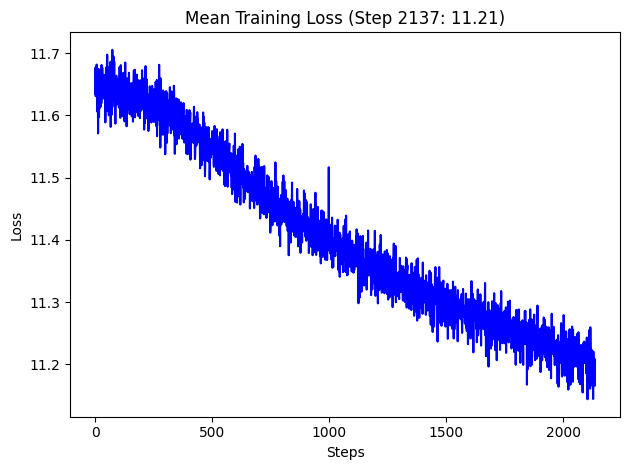

KeyboardInterrupt: 

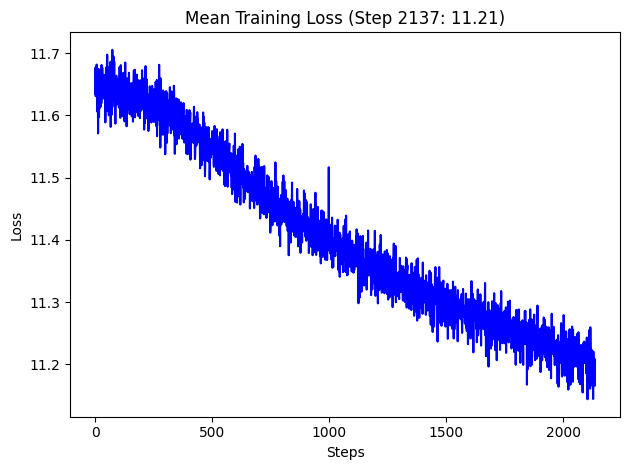

In [10]:
warmup_steps, train_steps = 500, 4500
d_model, heads, layers = 512, 8, 6
num_rows, batch_size, tokblk_size = 1500, 50, 128

train_dataset = WMT14("train", num_rows, tokblk_size)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Transformer(tokblk_size, train_dataset.vocab_size(), d_model, heads, layers).to(device)

lr_lambda = lambda step: (d_model ** -0.5) * min((step + 1) ** -0.5, (step + 1) * (warmup_steps ** -1.5))
optimizer = Adam(model.parameters(), lr=lr_lambda(1), betas=(0.9, 0.98), eps=1e-9)
scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.pad_token)

losses = []
fig, axs = plt.subplots()
train_model(model, criterion, train_loader, optimizer, scheduler,
            device, True, warmup_steps + train_steps, fig, axs, losses)

torch.save(model.state_dict(), "tiny-transformer-weights.pth")